In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Iterable
from matplotlib.patches import Patch  # Per creare elementi di legenda personalizzati

## prestazioni parallel_for_sure_n con n_blocchi (blocchi in cui si divide range di for) variabile

In [2]:
#a mano settali uguali a come runnato in cluster 
#set parameter
n_runs = 50
n_elems = 80
n_body_function = 80000 #costo singola iterazione
n_thread = [1,2,4,7,8] # hardcode in run...sh
size_queue = 64

In [20]:
#confronto for-single thread con par_for_sure_n con n_blocchi variabile
def plot_n_thread(data_for, data_par_for_n,title):
    fig, ax = plt.subplots(figsize=[10, 8])
    
    boxs = []
    ticks = []
    boxs.append(data_for)
    ticks.append("for")
    for i in range(len(data_par_for_n)):
        boxs.append(data_par_for_n[i])
        ticks.append(str(n_thread[i]))

    
    bplot = ax.boxplot(boxs, showfliers=False, patch_artist=True)

    ax.set(xlabel = 'n_thread',ylabel = 'Microseconds')
    ax.set_title( title, loc = 'left')
    ax.set_xticks(range(1,1+len(boxs)),ticks)

    # Colora ogni box
    colors = ['orange'] + ['blue'] * (len(bplot['boxes']) - 1)
    for box, color in zip(bplot['boxes'], colors):
        box.set_facecolor(color)

    # Crea legenda con Patch
    legend_handles = [
        Patch(facecolor='orange', label='for'),
        Patch(facecolor='blue', label='parallel_for')
    ]
    ax.legend(handles=legend_handles, loc='upper right')

    plt.figtext(0.48, 0.9, f"threadpool:n_thread({n_thread})  size_queue({size_queue})\nsetup: range_for({n_elems}),  n_operation_in_body_function({n_body_function*4})\nn_runs: {len(data_for)}", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))

In [21]:
!rm *.txt

In [ ]:
!./run_n_thread_variabile.sh 10 80 80000 64

In [26]:
# run test
dati_for = np.genfromtxt("test_for.txt",delimiter=',',dtype=int)[:-1]
dati_parallel_for_sure_n = []
for i,nb in enumerate(n_thread):
    dati_parallel_for_sure_n.append(np.genfromtxt("test_parallel_for_sure_"+str(nb)+".txt",delimiter=',',dtype=int)[:-1])

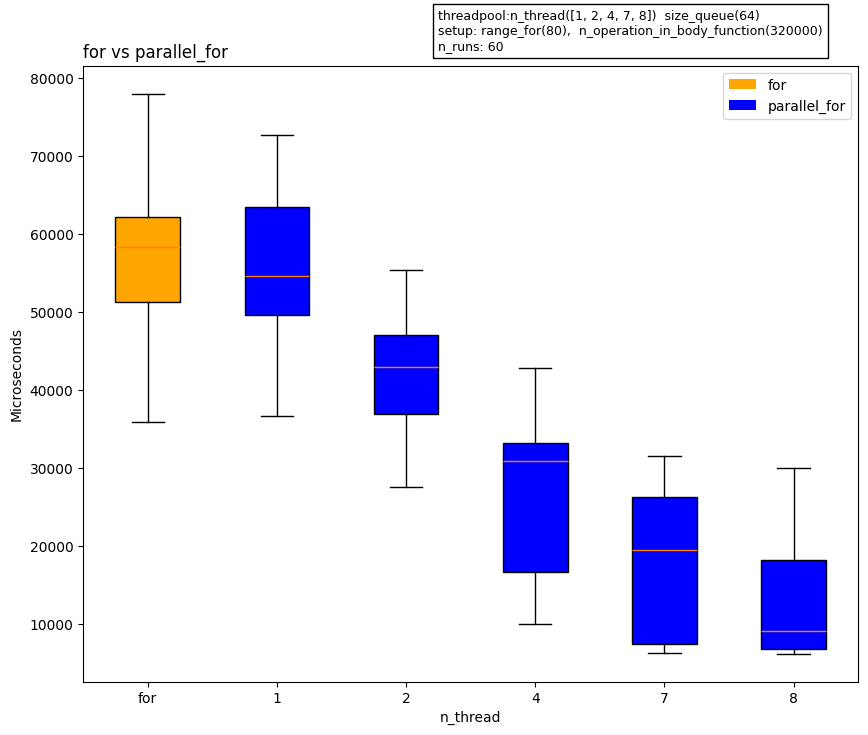

In [27]:
plot_n_thread(dati_for, dati_parallel_for_sure_n,"for vs parallel_for")


OSS: numero blocchi> n_thread --> pro:permette steal  contro: aumenta send.  

parallel_for_sure ha send massimo perche ogni iterazione di for iniziale è un job e performa male se tempo esecuzione job non sufficentemente grande da rendere tempo di send trascurabile  

TODO: capire ottimo numero blocchi in mezzo a questo trade-off, o lasciare che sia utente a trovarlo (per ora idea che sembra migliore) o in automatico dividere ogni blocco a sua volta in piu job in funzioje parallel_for_sure_n basandosi su criteri come numero worker tempo di singolo job e altre cose ma non saprei come fare e mi sembra eccessivo

In [28]:
def plot_speedup(data_list,title,n_threads): #primo data in data_list è for normale e poi si compara con quello
    fig, ax = plt.subplots(figsize=[16, 8])

    data_mean = [np.mean(datum) for datum in data_list]
    speedup = np.zeros(len(n_thread))


    for i in range(len(n_thread)):
        speedup[i] = data_mean[0]/data_mean[i+1]
        

    #print(data_list)
    #print(data_mean)
    ax.plot(n_thread,speedup,'o--')

    y = lambda x: np.minimum(x,n_threads)
    xx = np.array(n_thread)
    ax.plot(xx,y(xx),'o--')
    ax.legend(['speedup','maximum'])
    ax.set_title(title, loc= 'left')
    ax.set_xticks(n_thread)

    ax.set(xlabel = 'n_thread',ylabel = 'speedup')
    plt.figtext(0.6, 0.9, f"threadpool: n_thread({n_threads}), size_queue({size_queue})\nsetup: range_for({n_elems}), n_operation_in_body_function({n_body_function*4})\nn_runs: {len(data_list[0])}", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))

su 60 iniziali tenuti 53 per for sequential
su 60 iniziali tenuti 60 per n_thread 1
su 60 iniziali tenuti 58 per n_thread 2
su 60 iniziali tenuti 60 per n_thread 4
su 60 iniziali tenuti 60 per n_thread 7
su 60 iniziali tenuti 59 per n_thread 8


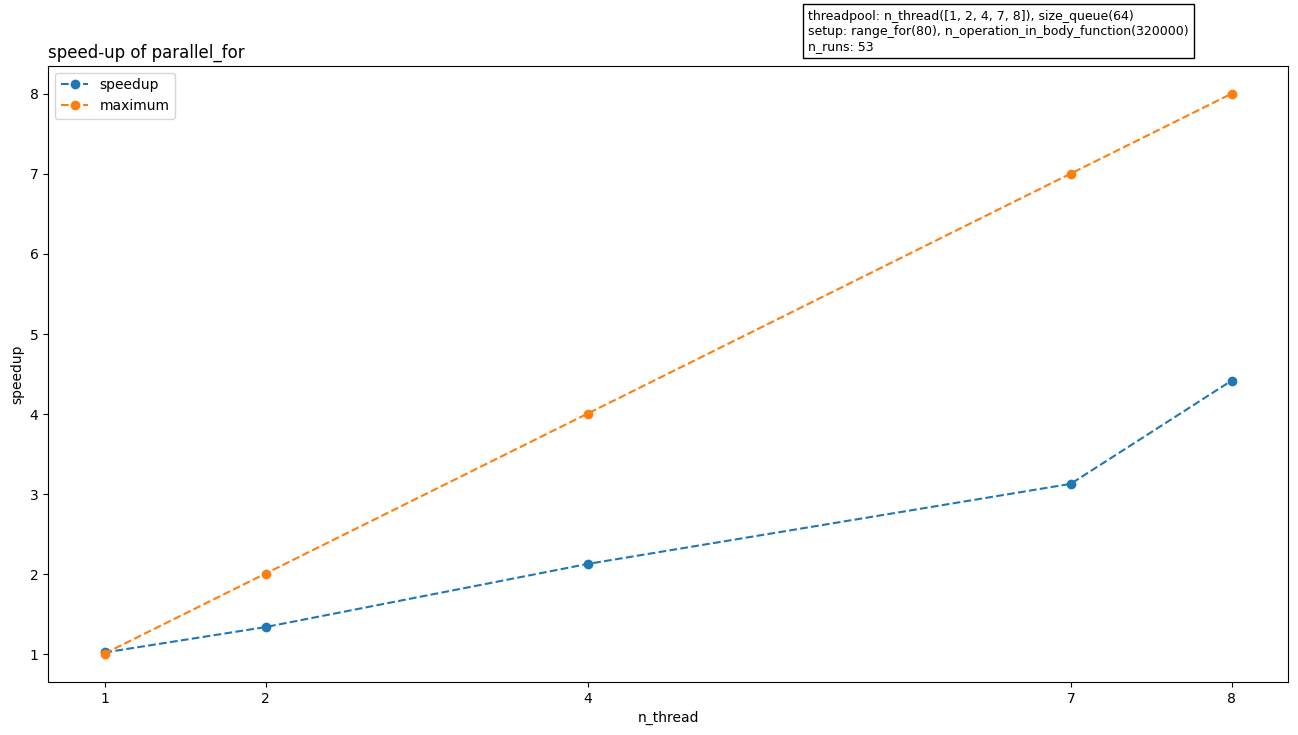

In [30]:
data_list = []
data_list.append(dati_for)
# Calcolo Q1, Q3 e IQR
Q1 = np.percentile(data_list[0], 25)
Q3 = np.percentile(data_list[0], 75)
IQR = Q3 - Q1

# Limiti per gli outlier
limite_inferiore = Q1 - 1 * IQR
limite_superiore = Q3 + 1 * IQR
#print(Q1,Q3,IQR,limite_inferiore,limite_superiore)
# Filtro
data_list[0] = data_list[0][(data_list[0] >= limite_inferiore) & (data_list[0] <= limite_superiore)]
print(f"su {len(dati_for)} iniziali tenuti {len(data_list[0])} per for sequential")
for i in range(len(n_thread)):
    data_list.append(dati_parallel_for_sure_n[i])
    # Calcolo Q1, Q3 e IQR
    Q1 = np.percentile(data_list[i+1], 25)
    Q3 = np.percentile(data_list[i+1], 75)
    IQR = Q3 - Q1

    # Limiti per gli outlier
    limite_inferiore = Q1 - 1 * IQR
    limite_superiore = Q3 + 1 * IQR
   # print(Q1,Q3,IQR,limite_inferiore,limite_superiore)
    # Filtro
    data_list[i+1] = data_list[i+1][(data_list[i+1] >= limite_inferiore) & (data_list[i+1] <= limite_superiore)]
    print(f"su {len(dati_parallel_for_sure_n[0])} iniziali tenuti {len(data_list[i+1])} per n_thread {n_thread[i]}")
plot_speedup(data_list,"speed-up of parallel_for",n_thread)

In [38]:
np.max(data_list[4])

np.int64(603858)